# 02b -- Do chromosomes influence pole positions?

## Motivation

In the standard picture of prometaphase, centrosome poles define the
spindle axis and chromosome-pole forces (e.g. kinetochore motors,
ejection forces) drive chromosomes toward the metaphase plate.  But do
the chromosomes also push or pull the poles?  If so, the pole midpoint
should drift toward whichever side is more crowded with chromosomes.

## Approach

We use the 12 rpe18_ctr cells with NEB annotations from the main
dataset.  For each cell and timepoint we measure:

- **3D distance between chromosome COM and pole midpoint** -- the full
  Euclidean distance between the center of mass of all chromosomes and
  the midpoint of the two centrosome poles.  This is our primary
  observable: if it shrinks over time, chromosomes and the spindle center
  are converging.

- **Count imbalance** at NEB -- the fraction of chromosomes on one side
  of the spindle midplane vs the other, `(n1 - n2) / n_total`.  This is
  our grouping variable: cells with a large count imbalance have a very
  lopsided chromosome distribution, while cells near zero are roughly
  symmetric.

We orient each cell's spindle axis so that the side with more
chromosomes at NEB maps to negative axial values ("pole 1").  This
canonical orientation is used only for the side-view plots (panels 1-3);
the 3D distance observable is direction-independent.

## Logic of the test

If poles are purely external (no back-reaction from chromosomes), the
rate at which the 3D chrom-COM-to-pole-midpoint distance shrinks should
not depend on the initial count imbalance -- chromosomes gather toward
the plate at a rate set by pole-chromosome forces, regardless of how
asymmetric the initial distribution is.

If chromosomes *do* exert forces on poles, then when the chromosome
cloud is lopsided the net pull on the nearer pole is stronger, shifting
the pole midpoint toward the crowded side.  Cells with large count
imbalance should therefore show faster convergence.

**Caveat:** A decreasing distance is consistent with both (a)
chromosomes gathering toward the midplane and (b) the pole midpoint
shifting toward chromosomes.  This analysis cannot fully separate the
two.  Regression-to-the-mean is also a confound for the binned
comparison.  We note both when interpreting.

**Status:** treat this notebook as exploratory only.  Its core
observable is the 3D distance between chromosome COM and pole
midpoint, which is not the right statistic for deciding whether
chromosomes measurably influence poles.  Notebook `02c` is the cleaner
model-free test, and notebook `03b` is the cleaner reconciliation of
the pole-influence and force-partition questions.

## Summary of panels

1. Side view (axial vs radial) of all chromosome positions at NEB.
2. Top-down view (perpendicular plane) at NEB.
3. Grouping: count imbalance per cell, with a colored side-view.
4. 3D chrom COM -- pole midpoint distance over time (with mean).
5. Change in 3D distance from NEB (with mean).
6. Asymmetry-binned: cells split by count imbalance (high vs low).
7. Continuous scatter: count imbalance vs convergence slope.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())

from chromlearn.io.catalog import load_condition
from chromlearn.io.trajectory import pole_center, pole_pole_distance, trim_trajectory

plt.rcParams["figure.dpi"] = 110

## Configuration

In [2]:
CONDITION = "rpe18_ctr"
FRAC = 0.4        # early gathering phase (NEB to 40% of AO)
MIN_FRAMES = 25

In [3]:
cells_raw = load_condition(CONDITION)
cells = []
for c in cells_raw:
    try:
        cells.append(trim_trajectory(c, method="neb_ao_frac", frac=FRAC, min_frames=MIN_FRAMES))
    except ValueError as e:
        print(f"  Skipping {c.cell_id}: {e}")
print(f"Loaded {len(cells)} {CONDITION} cells")

Loaded 12 rpe18_ctr cells


## Spindle-frame decomposition

We project chromosome positions onto the spindle axis (signed axial
coordinate, with pole midpoint at zero) and two perpendicular
directions.  For visualization we optionally apply a canonical
orientation so that the side with more chromosomes at NEB is always
negative ("pole 1").

In [4]:
def spindle_decompose(cell, canonicalize=True):
    """Decompose chromosome positions into spindle-axis and perpendicular components.

    Returns
    -------
    axial : (T, N)
    perp1, perp2 : (T, N)
    half_length : (T,)
    flipped : bool
    """
    p1 = cell.centrioles[:, :, 0]
    p2 = cell.centrioles[:, :, 1]
    center = 0.5 * (p1 + p2)
    axis = p2 - p1
    length = np.linalg.norm(axis, axis=1, keepdims=True)
    axis_unit = axis / np.where(length > 1e-12, length, 1.0)

    e1 = np.zeros_like(axis_unit)
    for t in range(len(axis_unit)):
        seed = np.array([1.0, 0.0, 0.0])
        if abs(np.dot(axis_unit[t], seed)) > 0.9:
            seed = np.array([0.0, 1.0, 0.0])
        v = seed - np.dot(seed, axis_unit[t]) * axis_unit[t]
        e1[t] = v / np.linalg.norm(v)
    e2 = np.cross(axis_unit, e1)

    delta = cell.chromosomes - center[:, :, np.newaxis]
    axial = np.einsum("tdi,td->ti", delta, axis_unit)
    perp1 = np.einsum("tdi,td->ti", delta, e1)
    perp2 = np.einsum("tdi,td->ti", delta, e2)
    half_length = length.squeeze() / 2.0

    flipped = False
    if canonicalize:
        ax0 = axial[0]
        valid = ~np.isnan(ax0)
        n_neg = np.sum(ax0[valid] < 0)
        n_pos = np.sum(ax0[valid] > 0)
        if n_pos > n_neg:
            axial = -axial
            perp1 = -perp1
            flipped = True

    return axial, perp1, perp2, half_length, flipped


def chrom_pole_distance_3d(cell):
    """3D Euclidean distance between chromosome COM and pole midpoint per frame."""
    pole_mid = 0.5 * (cell.centrioles[:, :, 0] + cell.centrioles[:, :, 1])
    chrom_com = np.nanmean(cell.chromosomes, axis=2)
    return np.linalg.norm(chrom_com - pole_mid, axis=1)


def count_imbalance(cell):
    """Chromosome count imbalance at NEB: (n_pole1 - n_pole2) / n_total.

    Uses the canonical orientation (pole 1 = crowded side, negative axial).
    Returns a value in [0, 1] where 0 = perfectly symmetric, 1 = all on one side.
    """
    axial, _, _, _, _ = spindle_decompose(cell, canonicalize=True)
    ax0 = axial[0]
    valid = ~np.isnan(ax0)
    n_neg = np.sum(ax0[valid] < 0)  # pole 1 side
    n_pos = np.sum(ax0[valid] > 0)  # pole 2 side
    n_total = n_neg + n_pos
    if n_total == 0:
        return 0.0
    return (n_neg - n_pos) / n_total  # always >= 0 after canonicalization

## 1. Side view at NEB: axial vs radial

All chromosome positions at the first frame (NEB), pooled across cells.
Axial coordinate normalized by half-spindle-length so poles sit at +/-1.

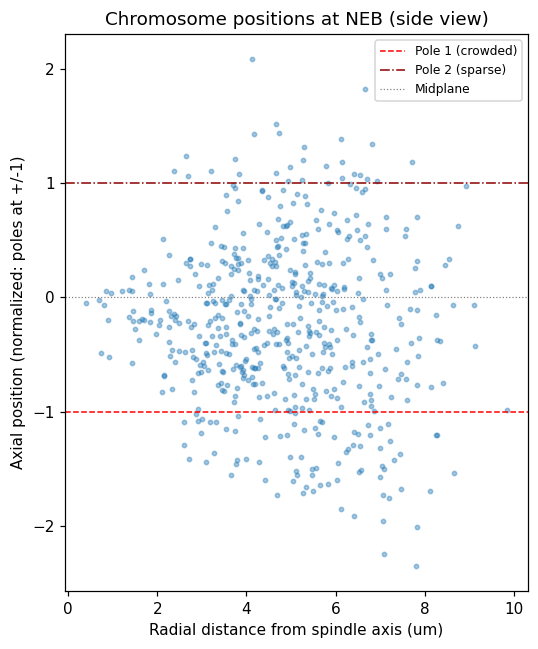

In [5]:
fig, ax = plt.subplots(figsize=(5, 6))
for cell in cells:
    axial, perp1, perp2, half_len, _ = spindle_decompose(cell)
    radial = np.sqrt(perp1[0] ** 2 + perp2[0] ** 2)
    ax_norm = axial[0] / half_len[0]
    ax.scatter(radial, ax_norm, s=8, alpha=0.4, color="C0")

ax.axhline(-1, color="red", ls="--", lw=1, label="Pole 1 (crowded)")
ax.axhline(+1, color="darkred", ls="-.", lw=1, label="Pole 2 (sparse)")
ax.axhline(0, color="gray", ls=":", lw=0.8, label="Midplane")
ax.set_xlabel("Radial distance from spindle axis (um)")
ax.set_ylabel("Axial position (normalized: poles at +/-1)")
ax.set_title("Chromosome positions at NEB (side view)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## 2. Top-down view at NEB: perpendicular plane

Looking along the spindle axis.  Each cell is a different color.

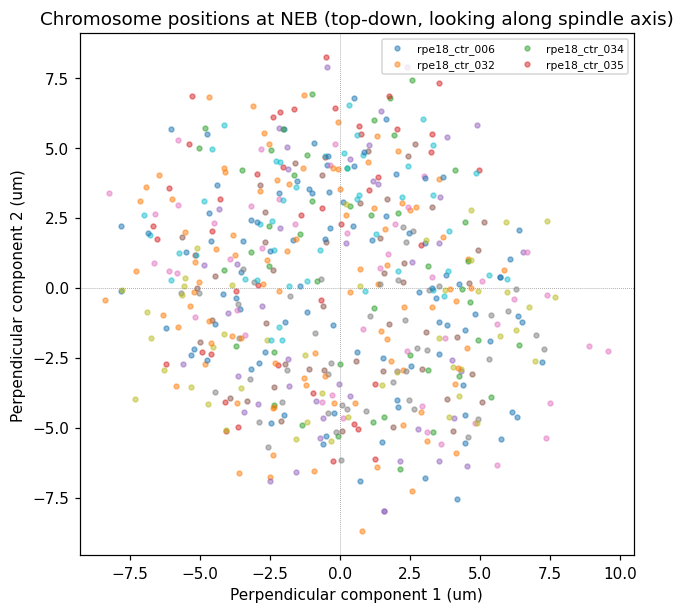

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
for i, cell in enumerate(cells):
    _, perp1, perp2, _, _ = spindle_decompose(cell)
    ax.scatter(perp1[0], perp2[0], s=10, alpha=0.5, label=cell.cell_id if i < 4 else None)
ax.set_xlabel("Perpendicular component 1 (um)")
ax.set_ylabel("Perpendicular component 2 (um)")
ax.set_aspect("equal")
ax.axhline(0, color="gray", ls=":", lw=0.5)
ax.axvline(0, color="gray", ls=":", lw=0.5)
ax.set_title("Chromosome positions at NEB (top-down, looking along spindle axis)")
ax.legend(fontsize=7, ncol=2, loc="upper right")
fig.tight_layout()
plt.show()

## 3. Grouping cells by chromosome count imbalance

For each cell at NEB we count how many chromosomes sit on each side of
the spindle midplane (the plane perpendicular to the pole-to-pole axis,
passing through the pole midpoint).  The **count imbalance** is:

$$\text{imbalance} = \frac{n_{\text{pole 1}} - n_{\text{pole 2}}}{n_{\text{total}}}$$

where pole 1 is canonically the side with more chromosomes.  A value of
0 means equal numbers on each side; a value of 1 would mean all
chromosomes on one side (never observed in practice).

We split the 12 cells at the median imbalance into a **high-imbalance**
group (orange, more lopsided) and a **low-imbalance** group (blue, more
symmetric).  The table below lists each cell's counts and group
assignment.  The scatter plot shows the same side-view as panel 1, now
colored by group, with a diamond marking each cell's chromosome COM.

In [7]:
# Compute count imbalance for each cell
imbalances = {}
for cell in cells:
    imbalances[cell.cell_id] = count_imbalance(cell)

imb_values = np.array(list(imbalances.values()))
median_imb = np.median(imb_values)

group_high_imb = [c for c in cells if imbalances[c.cell_id] >= median_imb]
group_low_imb = [c for c in cells if imbalances[c.cell_id] < median_imb]

print(f"Median count imbalance: {median_imb:.3f}\n")
print(f"{'Cell ID':<20s} {'n_chroms':>8s} {'n_pole1':>8s} {'n_pole2':>8s} {'imbalance':>10s}  Group")
print("-" * 70)
for cell in sorted(cells, key=lambda c: imbalances[c.cell_id], reverse=True):
    axial, _, _, _, _ = spindle_decompose(cell)
    ax0 = axial[0]
    v = ~np.isnan(ax0)
    n1 = int(np.sum(ax0[v] < 0))
    n2 = int(np.sum(ax0[v] > 0))
    imb = imbalances[cell.cell_id]
    grp = "HIGH" if imb >= median_imb else "low"
    print(f"{cell.cell_id:<20s} {n1+n2:8d} {n1:8d} {n2:8d} {imb:10.3f}  {grp}")

Median count imbalance: 0.261

Cell ID              n_chroms  n_pole1  n_pole2  imbalance  Group
----------------------------------------------------------------------
rpe18_ctr_006              46       37        9      0.609  HIGH
rpe18_ctr_035              46       35       11      0.522  HIGH
rpe18_ctr_506              46       33       13      0.435  HIGH
rpe18_ctr_505              46       31       15      0.348  HIGH
rpe18_ctr_501              46       30       16      0.304  HIGH
rpe18_ctr_049              46       29       17      0.261  HIGH
rpe18_ctr_502              46       29       17      0.261  HIGH
rpe18_ctr_509              46       27       19      0.174  low
rpe18_ctr_034              46       25       21      0.087  low
rpe18_ctr_043              46       25       21      0.087  low
rpe18_ctr_500              46       24       22      0.043  low
rpe18_ctr_032              46       23       23      0.000  low


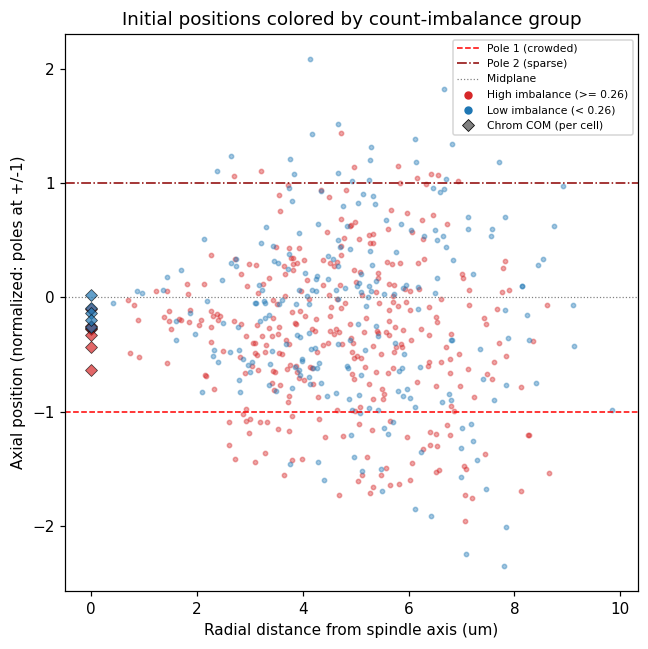

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
for group, color, label in [
    (group_high_imb, "C3", f"High imbalance (>= {median_imb:.2f})"),
    (group_low_imb, "C0", f"Low imbalance (< {median_imb:.2f})"),
]:
    for cell in group:
        axial, perp1, perp2, half_len, _ = spindle_decompose(cell)
        radial = np.sqrt(perp1[0] ** 2 + perp2[0] ** 2)
        ax_norm = axial[0] / half_len[0]
        ax.scatter(radial, ax_norm, s=8, alpha=0.4, color=color)
        # Diamond at chromosome COM
        com_norm = np.nanmean(ax_norm)
        ax.plot(0, com_norm, marker="D", ms=6, color=color, alpha=0.7,
                markeredgecolor="k", markeredgewidth=0.5, zorder=4)

ax.axhline(-1, color="red", ls="--", lw=1, label="Pole 1 (crowded)")
ax.axhline(+1, color="darkred", ls="-.", lw=1, label="Pole 2 (sparse)")
ax.axhline(0, color="gray", ls=":", lw=0.8, label="Midplane")
ax.scatter([], [], s=20, color="C3", label=f"High imbalance (>= {median_imb:.2f})")
ax.scatter([], [], s=20, color="C0", label=f"Low imbalance (< {median_imb:.2f})")
ax.plot([], [], marker="D", ms=6, color="gray", ls="none",
        markeredgecolor="k", markeredgewidth=0.5, label="Chrom COM (per cell)")
ax.set_xlabel("Radial distance from spindle axis (um)")
ax.set_ylabel("Axial position (normalized: poles at +/-1)")
ax.set_title("Initial positions colored by count-imbalance group")
ax.legend(loc="upper right", fontsize=7)
fig.tight_layout()
plt.show()

## 4. 3D chrom COM -- pole midpoint distance over time

The primary observable: full 3D Euclidean distance between the
chromosome center of mass and the pole midpoint.  Individual cell traces
(thin) plus the pooled mean (thick).

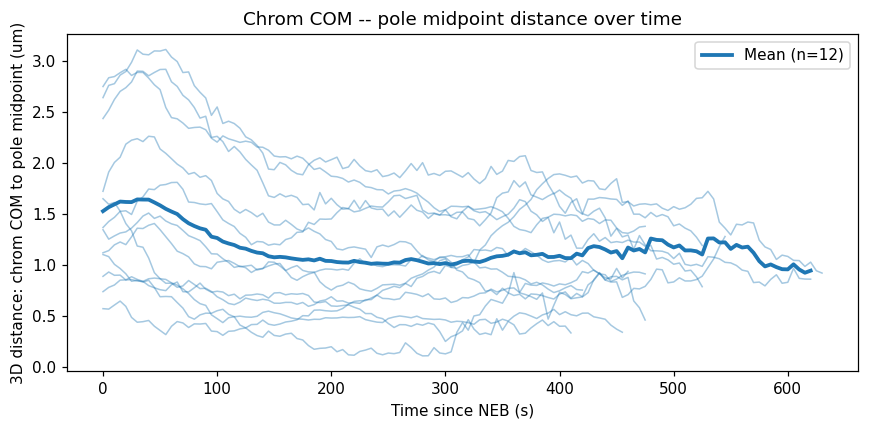

In [9]:
max_frames = max(c.chromosomes.shape[0] for c in cells)
time_grid = np.arange(max_frames) * cells[0].dt

fig, ax = plt.subplots(figsize=(8, 4))
all_dist = np.full((len(cells), max_frames), np.nan)
for i, cell in enumerate(cells):
    dist = chrom_pole_distance_3d(cell)
    all_dist[i, : len(dist)] = dist
    time = np.arange(len(dist)) * cell.dt
    ax.plot(time, dist, alpha=0.4, lw=1, color="C0")

valid = np.sum(~np.isnan(all_dist), axis=0) >= 2
ax.plot(time_grid[valid], np.nanmean(all_dist, axis=0)[valid],
        color="C0", lw=2.5, label=f"Mean (n={len(cells)})")
ax.set_xlabel("Time since NEB (s)")
ax.set_ylabel("3D distance: chrom COM to pole midpoint (um)")
ax.set_title("Chrom COM -- pole midpoint distance over time")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Change in 3D distance from NEB

Subtract the initial distance so all traces start at zero.  Negative
values mean the chromosome COM and pole midpoint are converging.

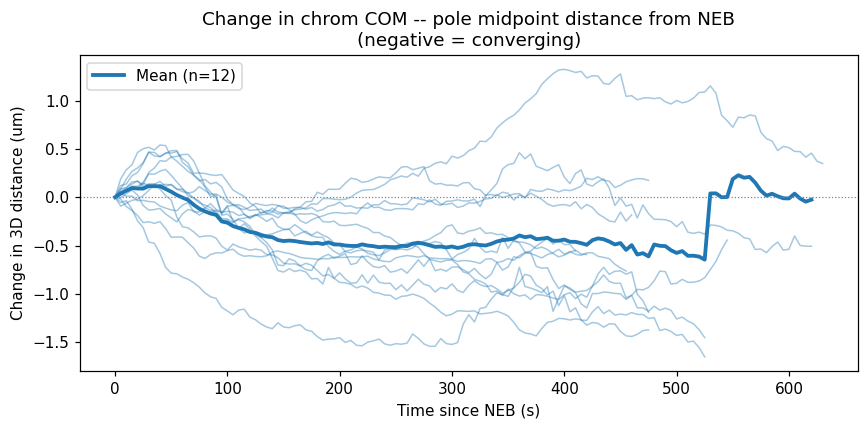

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
all_delta = np.full((len(cells), max_frames), np.nan)
for i, cell in enumerate(cells):
    dist = chrom_pole_distance_3d(cell)
    delta = dist - dist[0]
    all_delta[i, : len(delta)] = delta
    time = np.arange(len(delta)) * cell.dt
    ax.plot(time, delta, alpha=0.4, lw=1, color="C0")

valid = np.sum(~np.isnan(all_delta), axis=0) >= 2
ax.plot(time_grid[valid], np.nanmean(all_delta, axis=0)[valid],
        color="C0", lw=2.5, label=f"Mean (n={len(cells)})")
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.set_xlabel("Time since NEB (s)")
ax.set_ylabel("Change in 3D distance (um)")
ax.set_title("Change in chrom COM -- pole midpoint distance from NEB\n(negative = converging)")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Asymmetry-binned: 3D distance change by count imbalance

The key test.  We split cells into the high- and low-imbalance groups
from panel 3 and overlay their 3D distance traces in three views: raw
distance, absolute change from NEB, and fractional change (normalized
by starting distance).  The third panel controls for the geometric fact
that more-imbalanced cells start farther away -- if the groups overlap
in fractional terms, the absolute-change difference is an artifact.

**Note on regression-to-the-mean:** The count imbalance is not the same
variable as the 3D distance, which partially mitigates this concern.
Panel 7 provides a complementary continuous test that avoids binning.

C:\Users\Chris\AppData\Local\Temp\ipykernel_33536\1695952432.py:25: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(padded, axis=0)


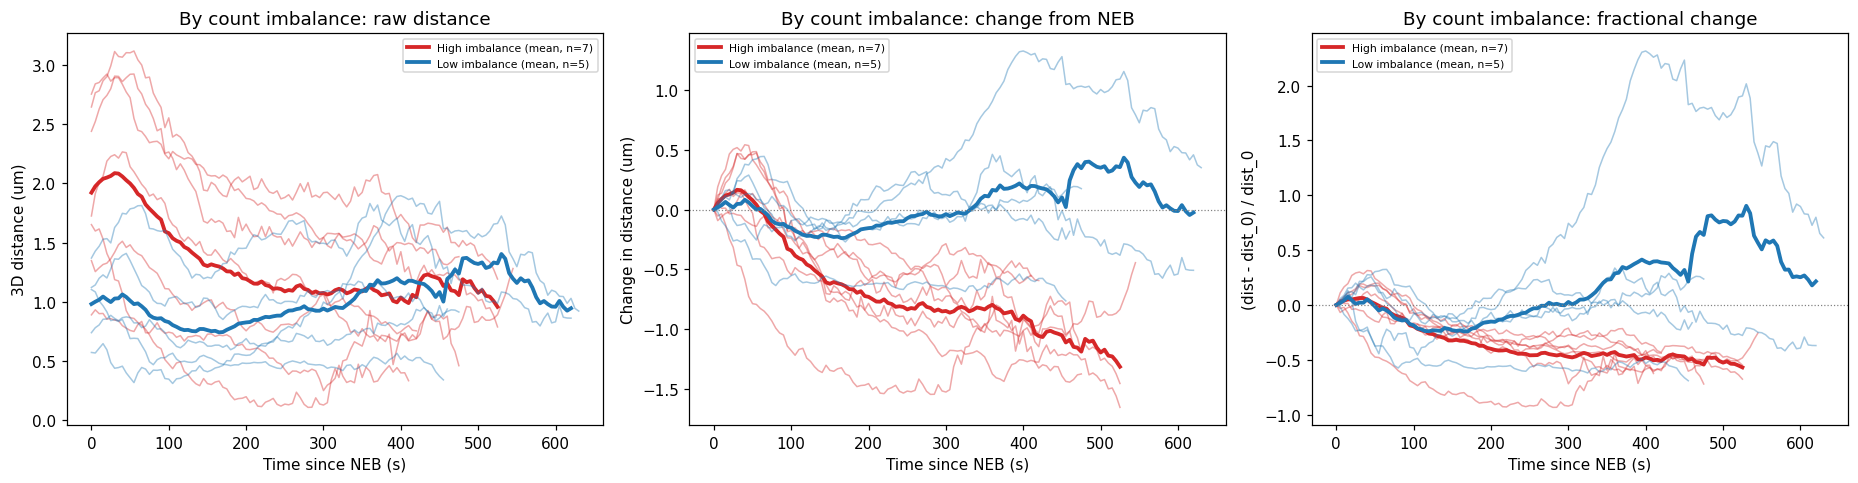

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, (title_suffix, ylabel, mode) in zip(axes, [
    ("raw distance", "3D distance (um)", "raw"),
    ("change from NEB", "Change in distance (um)", "abs"),
    ("fractional change", "(dist - dist_0) / dist_0", "frac"),
]):
    for group, color, label in [
        (group_high_imb, "C3", "High imbalance"),
        (group_low_imb, "C0", "Low imbalance"),
    ]:
        padded = np.full((len(group), max_frames), np.nan)
        for j, cell in enumerate(group):
            dist = chrom_pole_distance_3d(cell)
            if mode == "frac":
                val = (dist - dist[0]) / dist[0] if dist[0] > 1e-12 else dist * 0
            elif mode == "abs":
                val = dist - dist[0]
            else:
                val = dist
            padded[j, : len(val)] = val
            time = np.arange(len(val)) * cell.dt
            ax.plot(time, val, alpha=0.4, lw=1, color=color)

        mean_val = np.nanmean(padded, axis=0)
        gvalid = np.sum(~np.isnan(padded), axis=0) >= 2
        ax.plot(
            time_grid[gvalid],
            mean_val[gvalid],
            color=color,
            lw=2.5,
            label=f"{label} (mean, n={len(group)})",
        )

    if mode != "raw":
        ax.axhline(0, color="gray", ls=":", lw=0.8)
    ax.set_xlabel("Time since NEB (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"By count imbalance: {title_suffix}")
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

## 7. Continuous test: count imbalance vs convergence rate

One dot per cell.  x-axis: count imbalance at NEB (how lopsided the
chromosome distribution is).  y-axis: slope of the 3D distance change
over the first 60 seconds (linear fit; negative = converging).

A negative correlation (more-imbalanced cells converge faster) would
support the hypothesis that chromosomes influence pole positions.

Pearson r = -0.088, p = 0.786 (n = 12)


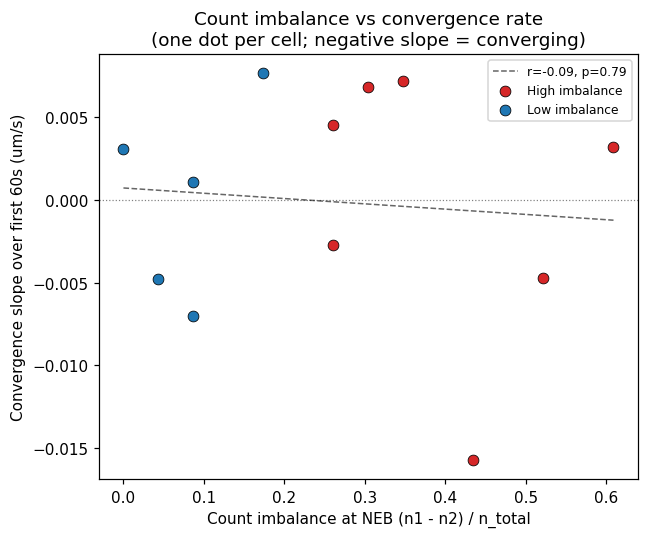

In [12]:
SLOPE_WINDOW_S = 60

imb_arr = []
slopes = []
cids = []

for cell in cells:
    dist = chrom_pole_distance_3d(cell)
    n_slope = min(len(dist), int(SLOPE_WINDOW_S / cell.dt) + 1)
    if n_slope < 3:
        continue
    t = np.arange(n_slope) * cell.dt
    delta = dist[:n_slope] - dist[0]
    slope = np.polyfit(t, delta, 1)[0]
    imb_arr.append(imbalances[cell.cell_id])
    slopes.append(slope)
    cids.append(cell.cell_id)

imb_arr = np.array(imb_arr)
slopes = np.array(slopes)

r, p = pearsonr(imb_arr, slopes)
print(f"Pearson r = {r:.3f}, p = {p:.3f} (n = {len(slopes)})")

fig, ax = plt.subplots(figsize=(6, 5))
for i, cid in enumerate(cids):
    color = "C3" if imbalances[cid] >= median_imb else "C0"
    ax.scatter(imb_arr[i], slopes[i], s=50, color=color,
               edgecolor="k", lw=0.5, zorder=3)
ax.axhline(0, color="gray", ls=":", lw=0.8)

if len(imb_arr) >= 3:
    m, b = np.polyfit(imb_arr, slopes, 1)
    x_range = np.linspace(imb_arr.min(), imb_arr.max(), 50)
    ax.plot(x_range, m * x_range + b, "k--", lw=1, alpha=0.6,
            label=f"r={r:.2f}, p={p:.2f}")

ax.scatter([], [], s=50, color="C3", edgecolor="k", lw=0.5, label="High imbalance")
ax.scatter([], [], s=50, color="C0", edgecolor="k", lw=0.5, label="Low imbalance")
ax.set_xlabel("Count imbalance at NEB (n1 - n2) / n_total")
ax.set_ylabel(f"Convergence slope over first {SLOPE_WINDOW_S}s (um/s)")
ax.set_title("Count imbalance vs convergence rate\n(one dot per cell; negative slope = converging)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Takeaway

This notebook is useful for intuition about asymmetric starting
configurations, but I would not use it as core evidence in the final
argument.  The chromosome COM distance conflates chromosome gathering,
pole translation, and spindle opening.  For the scientific question of
whether chromosomes leave a signature on pole motion, `02c` and `03b`
provide cleaner observables.